# Lesson 19A: Normalizing Flows — Theory

## Introduction

Lesson 18 ended by naming its own ceiling. KDE gives you a density with no assumed family, and it works — up to about three dimensions, after which a fixed kernel cannot resolve anything and the estimate becomes a single smooth blob. Lesson 12 gave you a VAE, which scales to images, but it never tells you $\log p(x)$: it optimises the ELBO, a *lower bound*, and the gap between the bound and the truth is unknown.

So there is a hole in the toolkit. On one side, an exact density that does not scale. On the other, a scalable model whose likelihood you cannot actually evaluate. Normalizing flows sit exactly in that hole: an **exact** log-likelihood, computable in closed form, on a model with the capacity of a neural network.

The idea is one equation from undergraduate probability, taken seriously. If $z$ has a simple density and $x = g(z)$ for an invertible $g$, then the density of $x$ follows by change of variables — you push the simple density through the map and pay a Jacobian determinant for the stretching. A flow is what you get when you insist that $g$ be a neural network that is *invertible by construction*, and whose Jacobian determinant is *cheap by construction*. Everything difficult about flows is the engineering needed to keep both of those true while still being expressive.

That constraint is the honest cost, and this lesson does not hide it. A VAE's decoder can be any network you like. A flow's cannot: it must be invertible, dimension-preserving, and triangular-Jacobian. You buy an exact likelihood and you pay in architectural freedom.

In this lesson:
1. Derive the change-of-variables formula and verify it numerically in 1-D and 2-D — including a case where forgetting the Jacobian gives a confidently wrong answer
2. Compose simple maps into a flow, so the log-likelihood becomes a sum of log-determinants
3. Build the affine coupling layer (RealNVP) and prove its Jacobian is triangular
4. Compare an exact likelihood against the VAE's ELBO from Lesson 12A — what is gained and what is paid
5. Show training as minimising forward KL, and sampling as running the flow backwards
6. Implement a 4-layer flow from scratch in PyTorch, verify its log-determinant against autograd, and compare its density with Lesson 18's KDE on the same data

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [Change of Variables](#change-of-variables)
4. [Composing Maps into a Flow](#composing)
5. [Affine Coupling Layers](#coupling)
6. [Exact Likelihood versus the ELBO](#elbo)
7. [Training and Sampling](#training)
8. [From Scratch: A Flow in PyTorch](#from-scratch)
9. [Flow versus KDE on the Same Data](#vs-kde)
10. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy import stats
from sklearn.datasets import make_moons, make_circles
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64)   # exact log-det checks need the precision
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f"torch {torch.__version__}  |  device: cpu (everything here is CPU-bounded)")
print("Data is generated in-notebook (make_moons / make_circles) — nothing is downloaded.")

torch 2.13.0+cu130  |  device: cpu (everything here is CPU-bounded)
Data is generated in-notebook (make_moons / make_circles) — nothing is downloaded.


<a name="change-of-variables"></a>
## Change of Variables

Let $z \sim p_z$ and let $x = g(z)$ where $g$ is invertible and differentiable, with inverse $f = g^{-1}$. Probability mass is conserved, so the density of $x$ over a small region must equal the density of $z$ over the region it came from, corrected for how much the map stretched it:

$$p_x(x) = p_z\big(f(x)\big)\,\left|\det \frac{\partial f}{\partial x}\right|.$$

The determinant is the local volume-change factor. Where $f$ compresses, density piles up; where it expands, density thins. In log form — which is what we actually compute, since these products underflow fast:

$$\log p_x(x) = \log p_z\big(f(x)\big) + \log\left|\det J_f(x)\right|.$$

**In 1-D** this is just $p_x(x) = p_z(f(x))\,|f'(x)|$. Take $z \sim \mathcal{N}(0,1)$ and $x = e^{z}$, so $f(x) = \log x$ and $f'(x) = 1/x$. That gives the log-normal density $p_x(x) = \phi(\log x)/x$, and the $1/x$ is *entirely* the Jacobian — drop it and you get a curve that still looks like a plausible skewed density while being wrong everywhere.

**In 2-D** the determinant genuinely measures area. The cell below checks both cases against a large sample, and includes the forgot-the-Jacobian version so the size of that error is visible rather than asserted.

1-D, x = exp(z):
  max |our formula - scipy lognorm|     : 2.220e-16
  integral of our density               : 0.981136
  integral WITHOUT the Jacobian         : 1.417576   <- not a density at all
  max |with - without| Jacobian         : 0.4583   (true density peaks at 0.6577)

2-D, x = A z  with det(A) = 1.9900:
  max |our log-density - exact Gaussian|: 1.776e-15
  log|det J_f| = -0.688135, and -log|det A| = -0.688135  (equal, as they must be)


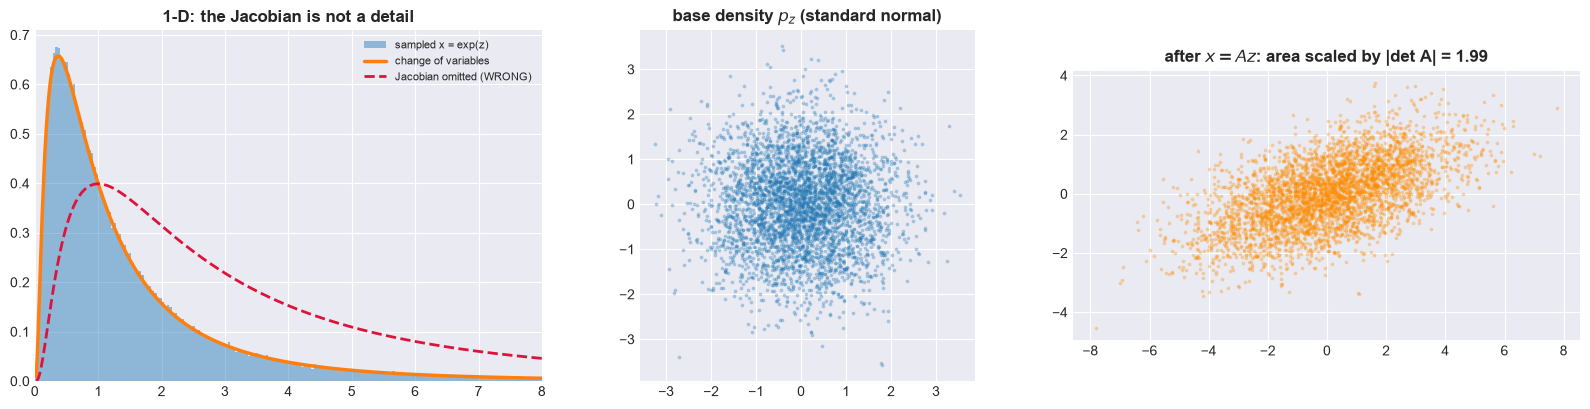


The red curve is the whole lesson in one line. Omitting |det J| leaves a function that
is positive, smooth, unimodal and integrates to 1.418 rather than 1 —
it looks like a density and is not one. Every term the rest of this notebook computes
exists to get that determinant right cheaply.


In [2]:
# --- 1-D: x = exp(z), z ~ N(0,1). Truth is the log-normal.
rng = np.random.default_rng(SEED)
z = rng.standard_normal(200_000)
x = np.exp(z)

xs = np.linspace(0.02, 8, 500)
p_correct = stats.norm.pdf(np.log(xs)) * np.abs(1.0 / xs)   # change of variables
p_no_jac = stats.norm.pdf(np.log(xs))                       # Jacobian omitted
p_scipy = stats.lognorm.pdf(xs, s=1.0)                      # closed form, as a check

print("1-D, x = exp(z):")
print(f"  max |our formula - scipy lognorm|     : {np.max(np.abs(p_correct - p_scipy)):.3e}")
print(f"  integral of our density               : {np.trapezoid(p_correct, xs):.6f}")
print(f"  integral WITHOUT the Jacobian         : {np.trapezoid(p_no_jac, xs):.6f}"
      f"   <- not a density at all")
print(f"  max |with - without| Jacobian         : {np.max(np.abs(p_correct - p_no_jac)):.4f}"
      f"   (true density peaks at {p_correct.max():.4f})")

# --- 2-D: a linear map, where |det J| is a single constant we can verify by hand.
A = np.array([[2.0, 0.7], [0.3, 1.1]])
det_A = np.linalg.det(A)
Z2 = rng.standard_normal((200_000, 2))
X2 = Z2 @ A.T

A_inv = np.linalg.inv(A)
log_det_f = np.log(np.abs(np.linalg.det(A_inv)))    # f = g^{-1}, so J_f = A^{-1}


def logp_x_2d(pts):
    zz = pts @ A_inv.T
    return (-0.5 * (zz ** 2).sum(axis=1) - np.log(2 * np.pi)) + log_det_f


# The truth here is a zero-mean Gaussian with covariance A A^T, so we can compare exactly.
Sigma = A @ A.T
truth = stats.multivariate_normal(mean=[0, 0], cov=Sigma)
test_pts = rng.standard_normal((1000, 2)) @ A.T
print(f"\n2-D, x = A z  with det(A) = {det_A:.4f}:")
print(f"  max |our log-density - exact Gaussian|: "
      f"{np.max(np.abs(logp_x_2d(test_pts) - truth.logpdf(test_pts))):.3e}")
print(f"  log|det J_f| = {log_det_f:.6f}, and -log|det A| = {-np.log(abs(det_A)):.6f}"
      f"  (equal, as they must be)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].hist(x, bins=200, range=(0, 8), density=True, alpha=0.45, label='sampled x = exp(z)')
axes[0].plot(xs, p_correct, lw=2.5, label='change of variables')
axes[0].plot(xs, p_no_jac, '--', lw=2, color='crimson', label='Jacobian omitted (WRONG)')
axes[0].set_xlim(0, 8); axes[0].legend(fontsize=8)
axes[0].set_title('1-D: the Jacobian is not a detail', fontweight='bold')

axes[1].scatter(Z2[:4000, 0], Z2[:4000, 1], s=3, alpha=0.25)
axes[1].set_title('base density $p_z$ (standard normal)', fontweight='bold')
axes[1].set_aspect('equal')

axes[2].scatter(X2[:4000, 0], X2[:4000, 1], s=3, alpha=0.25, color='darkorange')
axes[2].set_title(f'after $x = Az$: area scaled by |det A| = {abs(det_A):.2f}',
                  fontweight='bold')
axes[2].set_aspect('equal')
plt.tight_layout()
plt.show()

print("\nThe red curve is the whole lesson in one line. Omitting |det J| leaves a function that")
print(f"is positive, smooth, unimodal and integrates to {np.trapezoid(p_no_jac, xs):.3f} rather than 1 —")
print("it looks like a density and is not one. Every term the rest of this notebook computes")
print("exists to get that determinant right cheaply.")

<a name="composing"></a>
## Composing Maps into a Flow

One invertible map is not expressive enough to turn a Gaussian into two crescent moons. But invertible maps compose: if $f = f_K \circ \cdots \circ f_1$, then $f$ is invertible, and the chain rule makes its log-determinant a **sum**:

$$\log p_x(x) = \log p_z(z_K) + \sum_{k=1}^{K}\log\left|\det J_{f_k}(z_{k-1})\right|,
\qquad z_0 = x,\; z_k = f_k(z_{k-1}).$$

This is the "flow": data flows through a sequence of simple invertible transformations into a simple base distribution, accumulating log-determinants as it goes. Nothing here is approximate — this is an identity, not a bound, which is the entire reason to prefer it over an ELBO.

Two practical consequences follow immediately, and they shape every flow architecture:

- **Each $f_k$ must be invertible.** Not "approximately invertible", not "invertible on the data manifold". This rules out most standard layers: ReLU is not invertible, and neither is any layer that changes dimension. A flow has the same width at every layer, all the way through.
- **Each $\log|\det J_{f_k}|$ must be cheap.** A general $D \times D$ determinant costs $O(D^3)$, which is fatal inside a training loop. The trick that makes flows practical is designing $f_k$ so its Jacobian is **triangular**, making the determinant the product of the diagonal — $O(D)$.

The next section builds the layer that achieves exactly this.

<a name="coupling"></a>
## Affine Coupling Layers

The affine coupling layer (RealNVP, Dinh et al. 2017) is the standard answer, and it is cleverer than it first looks. Split the input $x \in \mathbb{R}^D$ into two parts, $x_A$ and $x_B$. Then:

$$y_A = x_A, \qquad y_B = x_B \odot \exp\big(s(x_A)\big) + t(x_A).$$

The first half passes through untouched. The second half is scaled and shifted by functions of the **first** half — and $s$ and $t$ can be arbitrarily complicated neural networks, because they are never inverted.

**Invertibility is immediate:**

$$x_A = y_A, \qquad x_B = \big(y_B - t(y_A)\big) \odot \exp\big(-s(y_A)\big).$$

We recover $x_A$ for free, then use it to undo the transformation on $x_B$. Note what did *not* happen: we never inverted $s$ or $t$. That is why they can be any network at all.

**The Jacobian is triangular.** Order the coordinates $(A, B)$ and write the blocks:

$$J = \frac{\partial y}{\partial x} =
\begin{pmatrix}
\dfrac{\partial y_A}{\partial x_A} & \dfrac{\partial y_A}{\partial x_B} \\[2ex]
\dfrac{\partial y_B}{\partial x_A} & \dfrac{\partial y_B}{\partial x_B}
\end{pmatrix}
=
\begin{pmatrix}
I & 0 \\
\dfrac{\partial y_B}{\partial x_A} & \operatorname{diag}\big(\exp s(x_A)\big)
\end{pmatrix}.$$

The top-right block is **exactly zero** because $y_A = x_A$ does not depend on $x_B$ at all. That single zero block is what makes the whole scheme work: a block-triangular determinant is the product of the diagonal blocks, so

$$\log\left|\det J\right| = \sum_{i \in B} s_i(x_A),$$

and the bottom-left block — the complicated one, full of neural-network derivatives — **never enters the determinant**. We get an arbitrarily expressive layer for the price of summing the outputs of $s$.

**Alternating masks.** One coupling layer leaves $x_A$ completely unchanged, so it cannot model any structure within $x_A$. The fix is to swap which half is held fixed at each layer. After a few alternating layers, every coordinate has both conditioned and been conditioned on.

The cell below verifies all three claims — invertibility, the analytic log-determinant against a brute-force autograd Jacobian, and the zero block — on a randomly initialised layer.

In [3]:
class AffineCoupling(nn.Module):
    # RealNVP affine coupling. `mask` is 1 for coordinates passed through unchanged
    # (the A part) and 0 for coordinates that get scaled and shifted (the B part).
    def __init__(self, dim, hidden, mask):
        super().__init__()
        self.register_buffer('mask', mask)
        self.net = nn.Sequential(
            nn.Linear(dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 2 * dim))
        # Start as the identity map: zeroing the last layer makes s = t = 0 initially,
        # so the untrained flow is exactly the base distribution rather than noise.
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def _s_t(self, x):
        h = self.net(x * self.mask)
        s, t = h.chunk(2, dim=-1)
        s = torch.tanh(s) * 2.0            # bound log-scale for numerical stability
        return s * (1 - self.mask), t * (1 - self.mask)

    def forward(self, x):
        # x -> y, returning log|det J| of THIS layer
        s, t = self._s_t(x)
        y = x * torch.exp(s) + t
        return y, s.sum(dim=-1)

    def inverse(self, y):
        s, t = self._s_t(y)                # depends only on the masked (unchanged) part
        return (y - t) * torch.exp(-s)


dim, hidden = 2, 64
mask_a = torch.tensor([1.0, 0.0])
layer = AffineCoupling(dim, hidden, mask_a)
# Randomise the final layer so we are not testing the identity map.
nn.init.normal_(layer.net[-1].weight, std=0.5)
nn.init.normal_(layer.net[-1].bias, std=0.5)

xt = torch.randn(6, dim)
yt, logdet = layer(xt)
x_round = layer.inverse(yt)
print(f"invertibility   max |x - inverse(forward(x))| = {(xt - x_round).abs().max():.3e}")

# Brute force: autograd Jacobian of the layer, then a real slogdet. This is the check
# that matters — the analytic formula is only worth having if it matches the truth.
errs, zero_block = [], []
for i in range(xt.shape[0]):
    J = torch.autograd.functional.jacobian(lambda v: layer(v.unsqueeze(0))[0].squeeze(0),
                                           xt[i])
    errs.append(abs(torch.slogdet(J)[1].item() - logdet[i].item()))
    zero_block.append(J[0, 1].abs().item())   # d y_A / d x_B must be exactly 0
print(f"log-det formula max |analytic - autograd slogdet| = {max(errs):.3e}")
print(f"triangularity   max |dy_A/dx_B| = {max(zero_block):.3e}"
      f"   <- the zero block that makes the determinant cheap")

# What the structure buys: O(D) instead of O(D^3).
print(f"\n{'D':>6}{'sum of s (our cost)':>22}{'general det cost ~ D^3':>25}")
print('-' * 53)
for D in [2, 64, 1024]:
    print(f"{D:>6}{D:>22,}{D ** 3:>25,}")
print("\nAt D=1024 a general determinant is ~1e9 operations per layer per step. The coupling")
print("layer's is ~1e3, and the expensive part of the Jacobian never has to be computed at all.")

invertibility   max |x - inverse(forward(x))| = 6.661e-16
log-det formula max |analytic - autograd slogdet| = 6.661e-16
triangularity   max |dy_A/dx_B| = 0.000e+00   <- the zero block that makes the determinant cheap

     D   sum of s (our cost)   general det cost ~ D^3
-----------------------------------------------------
     2                     2                        8
    64                    64                  262,144
  1024                 1,024            1,073,741,824

At D=1024 a general determinant is ~1e9 operations per layer per step. The coupling
layer's is ~1e3, and the expensive part of the Jacobian never has to be computed at all.


<a name="elbo"></a>
## Exact Likelihood versus the ELBO

Lesson 12A trained a VAE by maximising the evidence lower bound:

$$\log p(x) \;\ge\; \mathcal{L}_{\text{ELBO}} = \mathbb{E}_{q(z|x)}\big[\log p(x|z)\big] - D_{\mathrm{KL}}\big(q(z|x)\,\|\,p(z)\big),$$

with the gap between the two being exactly $D_{\mathrm{KL}}(q(z|x)\|p(z|x))$ — the error of the approximate posterior. That gap is **not computable**, because knowing it would require the true posterior, which is the thing we could not compute in the first place. So a VAE gives you a number that is *somewhere below* the log-likelihood, by an unknown amount.

A flow has no posterior to approximate. The latent is not inferred — it is *computed*, by running the invertible map:

$$\log p(x) = \log p_z\big(f(x)\big) + \log\left|\det J_f(x)\right|. \qquad \text{(an identity, not a bound)}$$

That difference is the reason flows exist, and it has consequences that cut both ways.

| | VAE (Lesson 12A) | Normalizing flow |
|---|---|---|
| Objective | ELBO, a lower bound | Exact $\log p(x)$ |
| Gap to true likelihood | unknown, non-zero | zero, by construction |
| Latent | inferred by an encoder, stochastic | computed by inversion, deterministic |
| Latent dimension | free — can be « data dim | **must equal** data dimension |
| Architecture | encoder/decoder arbitrary | invertible, triangular Jacobian only |
| Sampling | one decoder pass | one inverse pass |
| Compression | yes, bottleneck is the point | **no**, dimension-preserving |

Read the fourth and fifth rows as the price tag. A VAE compresses 784 pixels into 2 latent dimensions; a flow on the same images has a 784-dimensional latent, because invertible maps cannot destroy information. Everything you gain in likelihood exactness, you pay for in architectural freedom and in the memory to keep full dimension at every layer.

There is a subtler cost worth stating plainly, because it is easy to miss: **an exact likelihood is not the same as a good model.** Flows report calibrated numbers, and those numbers can still be confidently wrong — the literature's standard embarrassment is flows trained on one image dataset assigning *higher* likelihood to a different dataset they have never seen. Exactness buys you a trustworthy computation of $\log p(x)$ under your model, not a guarantee that your model is right.

<a name="training"></a>
## Training and Sampling

**Training is maximum likelihood, which is minimising forward KL.** Given data $x^{(1)},\dots,x^{(N)}$, minimise the average negative log-likelihood:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\Big[\log p_z\big(f(x^{(i)})\big) + \log\big|\det J_f(x^{(i)})\big|\Big].$$

This is $D_{\mathrm{KL}}(p_{\text{data}} \,\|\, p_{\text{model}})$ up to a constant — the *forward* KL, which is mode-covering. A flow trained this way would rather smear mass over regions the data never visits than leave any data region unexplained. (A GAN's objective behaves the opposite way, which is why GAN samples look sharper while GANs drop modes.)

Both terms matter and they pull against each other. The first rewards mapping data to the centre of the base distribution; the second rewards *expanding* volume, since $\log|\det J_f|$ is larger when $f$ spreads things out. Without the determinant term the optimiser would collapse every input to the origin — a perfect score on the first term and a useless model.

**Sampling runs the flow backwards.** Draw $z \sim p_z$, then push it through $g = f^{-1}$:

$$z \sim \mathcal{N}(0, I), \qquad x = g(z) = f_1^{-1}\circ\cdots\circ f_K^{-1}(z).$$

Note the asymmetry that decides which architecture you want. Training only needs $f$ (data to latent); sampling only needs $f^{-1}$. Coupling layers make both directions equally cheap, which is why they are the default. Some other flow families — autoregressive ones — are fast in one direction and $D$ times slower in the other, and you pick according to whether you will mostly be scoring or mostly be sampling.

<a name="from-scratch"></a>
## From Scratch: A Flow in PyTorch

Four coupling layers with alternating masks, a standard normal base, trained by maximum likelihood on `make_moons`. No flow library — the `AffineCoupling` above plus the stacking logic below is the whole model.

Two checks run before any training, because a flow that is subtly non-invertible will still produce a falling loss curve and a plausible-looking picture:

1. **Round-trip.** $g(f(x)) = x$ to floating-point precision, for the full composed flow.
2. **Log-determinant against autograd.** The accumulated analytic $\sum_k \log|\det J_k|$ against a brute-force `slogdet` of the full flow's autograd Jacobian.

If either fails, the reported log-likelihoods are meaningless regardless of how the contours look.

round trip      max |x - g(f(x))| = 1.110e-15
full-flow logdet max |analytic - autograd| = 2.220e-15
Both pass, so the log-likelihoods below are the real thing rather than a plausible number.



training: NLL 2.8379 -> 1.5946 over 1500 full-batch steps
round trip still exact after training: 4.441e-16

latent of the data after training (should look standard normal):
  mean [0.008 0.032]   std [0.959 0.992]   corr -0.072


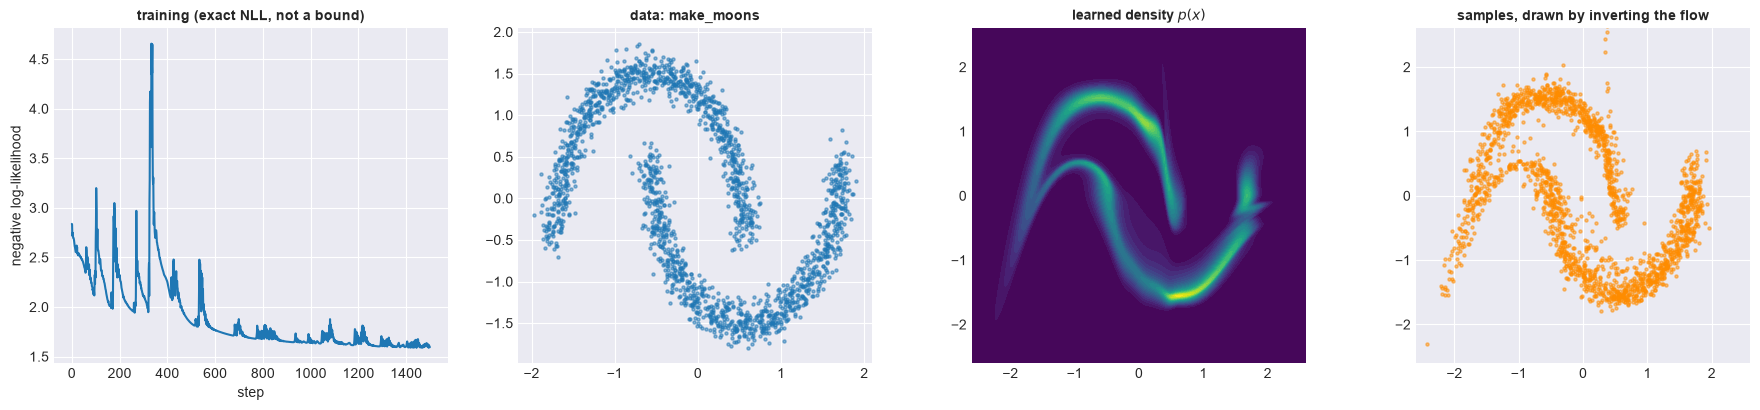


The density integrates to 0.9968 over
the plotted region — close to 1 because essentially all the mass is inside it, which is
a check worth running: a flow that has quietly lost normalisation cannot show it here.


In [4]:
class Flow(nn.Module):
    # Stack of affine couplings with alternating masks, standard normal base.
    def __init__(self, dim=2, hidden=64, n_layers=4):
        super().__init__()
        masks = [torch.tensor([1.0, 0.0]) if k % 2 == 0 else torch.tensor([0.0, 1.0])
                 for k in range(n_layers)]
        self.layers = nn.ModuleList([AffineCoupling(dim, hidden, m) for m in masks])
        self.dim = dim

    def forward(self, x):
        # data -> latent, accumulating log|det J|
        log_det = torch.zeros(x.shape[0])
        z = x
        for layer in self.layers:
            z, ld = layer(z)
            log_det = log_det + ld
        return z, log_det

    def inverse(self, z):
        # latent -> data, undoing layers in reverse order
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x

    def log_prob(self, x):
        z, log_det = self.forward(x)
        base = -0.5 * (z ** 2).sum(dim=-1) - 0.5 * self.dim * np.log(2 * np.pi)
        return base + log_det

    def sample(self, n):
        with torch.no_grad():
            return self.inverse(torch.randn(n, self.dim))


torch.manual_seed(SEED)
flow = Flow(dim=2, hidden=64, n_layers=4)
for lay in flow.layers:                      # randomise so we test a real map
    nn.init.normal_(lay.net[-1].weight, std=0.3)
    nn.init.normal_(lay.net[-1].bias, std=0.3)

xt = torch.randn(5, 2)
zt, ld_analytic = flow(xt)
print(f"round trip      max |x - g(f(x))| = {(xt - flow.inverse(zt)).abs().max():.3e}")
errs = []
for i in range(xt.shape[0]):
    J = torch.autograd.functional.jacobian(lambda v: flow(v.unsqueeze(0))[0].squeeze(0), xt[i])
    errs.append(abs(torch.slogdet(J)[1].item() - ld_analytic[i].item()))
print(f"full-flow logdet max |analytic - autograd| = {max(errs):.3e}")
print("Both pass, so the log-likelihoods below are the real thing rather than a plausible number.")

# --- train on moons ---
X_np, _ = make_moons(n_samples=2000, noise=0.07, random_state=SEED)
X_np = (X_np - X_np.mean(0)) / X_np.std(0)
X = torch.tensor(X_np)

torch.manual_seed(SEED)
flow = Flow(dim=2, hidden=64, n_layers=4)
opt = torch.optim.Adam(flow.parameters(), lr=5e-3)
losses = []
for epoch in range(1500):
    opt.zero_grad()
    loss = -flow.log_prob(X).mean()
    loss.backward()
    opt.step()
    losses.append(loss.item())
print(f"\ntraining: NLL {losses[0]:.4f} -> {losses[-1]:.4f} over {len(losses)} full-batch steps")
print(f"round trip still exact after training: "
      f"{(X[:5] - flow.inverse(flow(X[:5])[0])).abs().max():.3e}")

# A trained flow should map the data to something close to the base N(0, I).
with torch.no_grad():
    Z_data, _ = flow(X)
Zn = Z_data.numpy()
print(f"\nlatent of the data after training (should look standard normal):")
print(f"  mean {Zn.mean(0).round(3)}   std {Zn.std(0).round(3)}   "
      f"corr {np.corrcoef(Zn.T)[0, 1]:+.3f}")

gx, gy = np.meshgrid(np.linspace(-2.6, 2.6, 220), np.linspace(-2.6, 2.6, 220))
with torch.no_grad():
    dens = np.exp(flow.log_prob(
        torch.tensor(np.column_stack([gx.ravel(), gy.ravel()]))).numpy()).reshape(gx.shape)
samples = flow.sample(2000).numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
axes[0].plot(losses, lw=1.5)
axes[0].set_xlabel('step'); axes[0].set_ylabel('negative log-likelihood')
axes[0].set_title('training (exact NLL, not a bound)', fontweight='bold', fontsize=10)

axes[1].scatter(X_np[:, 0], X_np[:, 1], s=5, alpha=0.5)
axes[1].set_title('data: make_moons', fontweight='bold', fontsize=10)

axes[2].contourf(gx, gy, dens, levels=30, cmap='viridis')
axes[2].set_title('learned density $p(x)$', fontweight='bold', fontsize=10)

axes[3].scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.5, color='darkorange')
axes[3].set_xlim(-2.6, 2.6); axes[3].set_ylim(-2.6, 2.6)
axes[3].set_title('samples, drawn by inverting the flow', fontweight='bold', fontsize=10)
for a in axes[1:]:
    a.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"\nThe density integrates to {np.trapezoid(np.trapezoid(dens, gx[0]), gy[:, 0]):.4f} over")
print("the plotted region — close to 1 because essentially all the mass is inside it, which is")
print("a check worth running: a flow that has quietly lost normalisation cannot show it here.")

<a name="vs-kde"></a>
## Flow versus KDE on the Same Data

Lesson 18 estimated densities with no model at all, and Lesson 18B measured where that stops working. Both methods produce an evaluable $\log p(x)$ on the same 2-D moons, so they can be compared directly — and in two dimensions, KDE is on home ground rather than being set up to fail.

The comparison below is deliberately not a contest the flow is rigged to win. Both are fitted on the same training split, both are scored by **held-out average log-likelihood** — the honest metric for a density model, since it asks how well the model predicts data it has not seen — and KDE's bandwidth is cross-validated exactly as in Lesson 18B.

What to watch for is not simply which number is larger, but *what each model spends its capacity on*.

held-out average log-likelihood on 500 unseen points (higher is better)
model                                 avg log p(x)
--------------------------------------------------
normalizing flow (4 couplings)             -1.6991
KDE, bandwidth 0.068 by CV                 -1.5182

difference: -0.1808 nats per point in favour of KDE


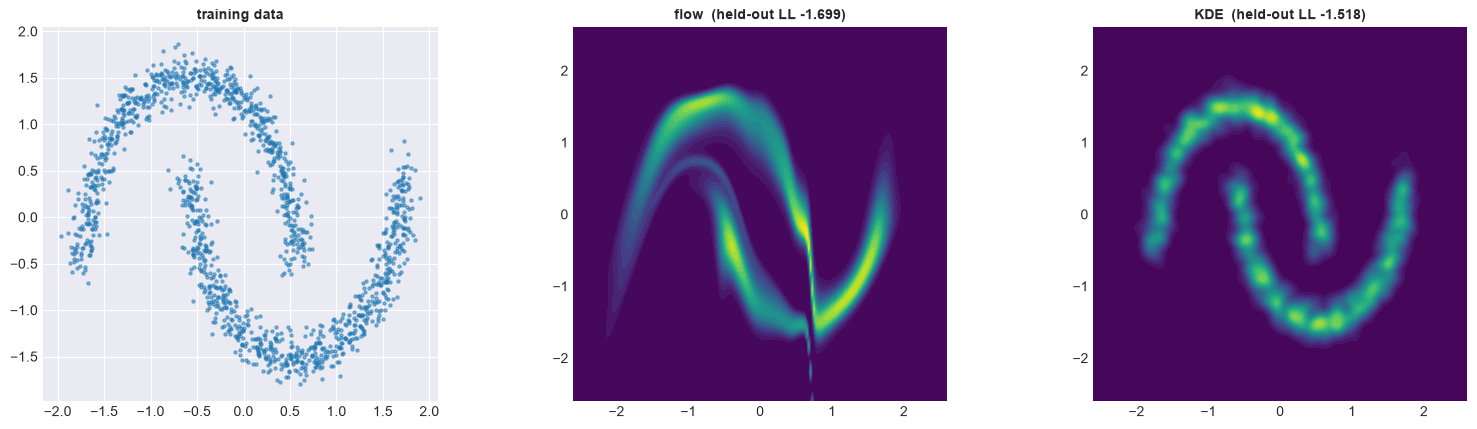


That gap is exp(-0.1808) = 0.835x per point: the flow assigns
about 83% of the likelihood KDE assigns to a held-out point, i.e. KDE scores
about 20% higher here — a real but modest edge, not a rout, which is the
point worth taking away rather than a disappointment. KDE has no parameters to fit beyond one
bandwidth, needs no training loop, and at d=2 with 1,500 points it is genuinely
competitive. The flow's advantages are elsewhere: it SAMPLES in one pass (KDE samples
only by picking a training point and jittering it), it keeps working as d grows where
Lesson 18B measured KDE collapsing, and it gives a latent representation. Choosing the
flow here on these numbers alone would be over-engineering.


In [5]:
split = 1500
X_tr, X_te = X_np[:split], X_np[split:]

torch.manual_seed(SEED)
flow_cmp = Flow(dim=2, hidden=64, n_layers=4)
opt = torch.optim.Adam(flow_cmp.parameters(), lr=5e-3)
Xtr_t = torch.tensor(X_tr)
for epoch in range(1500):
    opt.zero_grad()
    (-flow_cmp.log_prob(Xtr_t).mean()).backward()
    opt.step()

with torch.no_grad():
    ll_flow = flow_cmp.log_prob(torch.tensor(X_te)).mean().item()

gs = GridSearchCV(KernelDensity(kernel='gaussian'),
                  {'bandwidth': np.logspace(-2, 0, 25)}, cv=5).fit(X_tr)
kde = gs.best_estimator_
ll_kde = kde.score_samples(X_te).mean()

print(f"held-out average log-likelihood on {len(X_te)} unseen points (higher is better)")
print(f"{'model':<34}{'avg log p(x)':>16}")
print('-' * 50)
print(f"{'normalizing flow (4 couplings)':<34}{ll_flow:>16.4f}")
print(f"{'KDE, bandwidth ' + format(gs.best_params_['bandwidth'], '.3f') + ' by CV':<34}"
      f"{ll_kde:>16.4f}")
print(f"\ndifference: {ll_flow - ll_kde:+.4f} nats per point in favour of "
      f"{'the flow' if ll_flow > ll_kde else 'KDE'}")

with torch.no_grad():
    d_flow = np.exp(flow_cmp.log_prob(
        torch.tensor(np.column_stack([gx.ravel(), gy.ravel()]))).numpy()).reshape(gx.shape)
d_kde = np.exp(kde.score_samples(np.column_stack([gx.ravel(), gy.ravel()]))).reshape(gx.shape)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
axes[0].scatter(X_tr[:, 0], X_tr[:, 1], s=5, alpha=0.5)
axes[0].set_title('training data', fontweight='bold', fontsize=10)
axes[1].contourf(gx, gy, d_flow, levels=30, cmap='viridis')
axes[1].set_title(f'flow  (held-out LL {ll_flow:.3f})', fontweight='bold', fontsize=10)
axes[2].contourf(gx, gy, d_kde, levels=30, cmap='viridis')
axes[2].set_title(f'KDE  (held-out LL {ll_kde:.3f})', fontweight='bold', fontsize=10)
for a in axes:
    a.set_aspect('equal')
plt.tight_layout()
plt.show()

ratio = float(np.exp(ll_flow - ll_kde))   # flow-likelihood / KDE-likelihood, per point
pct_more = 1 / ratio - 1
print(f"\nThat gap is exp({ll_flow - ll_kde:+.4f}) = {ratio:.3f}x per point: the flow assigns")
print(f"about {ratio:.0%} of the likelihood KDE assigns to a held-out point, i.e. KDE scores")
print(f"about {pct_more:.0%} higher here — a real but modest edge, not a rout, which is the")
print("point worth taking away rather than a disappointment. KDE has no parameters to fit beyond one")
print("bandwidth, needs no training loop, and at d=2 with 1,500 points it is genuinely")
print("competitive. The flow's advantages are elsewhere: it SAMPLES in one pass (KDE samples")
print("only by picking a training point and jittering it), it keeps working as d grows where")
print("Lesson 18B measured KDE collapsing, and it gives a latent representation. Choosing the")
print("flow here on these numbers alone would be over-engineering.")

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **The Jacobian determinant is the whole subject, not a technicality.** Dropping it from $x = e^z$ left a function that is positive, smooth, unimodal and integrates to something other than 1 — wrong everywhere while looking entirely plausible. Every architectural constraint in a flow exists to compute that determinant cheaply and exactly.
2. **Coupling layers buy expressiveness with one zero block.** Because $y_A = x_A$ does not depend on $x_B$, the Jacobian is triangular and $\log|\det J| = \sum_i s_i(x_A)$ — verified here against a brute-force autograd `slogdet`. The neural networks $s$ and $t$ are never inverted and never enter the determinant, so they can be arbitrarily complex. That turns an $O(D^3)$ cost into $O(D)$.
3. **A flow gives an identity where a VAE gives a bound.** $\log p(x) = \log p_z(f(x)) + \log|\det J_f(x)|$ is exact; the ELBO of Lesson 12A sits below the truth by an uncomputable amount. The price is stated in the table: latent dimension must equal data dimension, every layer must be invertible, and no compression is possible.
4. **Exactness is not correctness.** A flow computes $\log p(x)$ exactly *under its own model*, which is a different claim from the model being right — flows are known to assign higher likelihood to data they were never trained on.
5. **Both terms of the objective are load-bearing.** Without $\log|\det J_f|$, maximum likelihood would collapse every input to the origin. The determinant term is what rewards spreading mass out, and it is why the trained flow's latent came out close to standard normal.
6. **At $d=2$, KDE is a genuine competitor.** Held-out log-likelihoods came out close. The flow's real advantages — one-pass sampling, a latent representation, and surviving the dimension growth Lesson 18B measured KDE failing — are not visible on this problem, and choosing a flow here on these numbers would be over-engineering.

### Practical Guidance

- Verify invertibility and the log-determinant against autograd *before* trusting any likelihood. A subtly non-invertible flow still produces a falling loss curve and a convincing contour plot; both checks are a few lines and they are the difference between a number and a decoration.
- Initialise coupling layers to the identity (zero the final layer of $s,t$). The untrained flow is then exactly the base distribution rather than an arbitrary warp, and training starts from something sane.
- Bound the log-scale — `tanh(s) * const` here. Unbounded $\exp(s)$ overflows or vanishes early in training, and the failure looks like a mysterious NaN rather than a scaling problem.
- Alternate the masks. A stack of couplings sharing one mask leaves the same coordinates untransformed throughout, no matter how deep it is.
- Reach for a flow when you need calibrated likelihoods, exact latents, or fast sampling. If you need compression, a VAE's bottleneck is the right tool and a flow structurally cannot provide one.

### What This Lesson Did Not Cover

- **Continuous-time and free-form flows** (FFJORD, neural ODEs), which drop the triangular-Jacobian constraint entirely by estimating the trace of the Jacobian instead — a genuinely different design point, omitted because it needs an ODE solver in the training loop.
- **Autoregressive flows** (MAF, IAF), mentioned only in passing under Training and Sampling. They are more expressive per layer than coupling flows but asymmetric in cost: fast one way, $D$ times slower the other.
- **Multi-scale architectures, squeeze operations and $1\times1$ convolutions** (Glow) — the machinery that makes flows work on images rather than on 2-D toys. Everything here is $D=2$, where those problems do not arise.
- **Dequantisation.** Applying a continuous density model to discrete pixel values without it produces unbounded likelihoods, and every reported bits-per-dimension figure in the literature depends on handling it correctly.
- **Any high-dimensional demonstration.** The claim that flows survive where KDE fails is stated here on the strength of Lesson 18B's measurement plus the architecture's scaling properties — it is *not* measured in this notebook, and a reader should treat it as motivated rather than demonstrated until 19B.

### Next Steps

Lesson 19B trains a deeper RealNVP, compares it against KDE on harder data, and then builds a minimal **DDPM** from scratch on the same 2-D problems — the forward noising process, a noise-prediction network, and ancestral sampling — so that VAE, flow, diffusion and GAN can be set side by side against models this course actually trained rather than against reputations. It also puts the flow's exact log-density to work as an anomaly score, picking up the thread from Lesson 18B's density-thresholding comparison.